[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DVPombo/SOLETE/blob/main/examples/05_hybrid_forecasting.ipynb)

# 05 — Hybrid wind+solar forecasting (`P_hybrid[kW]`)

**Headline finding, upfront, so it isn't missed by skimming to the numbers:** this
notebook packages the infrastructure for hybrid wind+solar forecasting on SOLETE — a
derived `P_hybrid[kW]` column, a joint-vs-independent forecasting comparison, and a
ramp-rate/volatility analysis — but **this specific 15-month record cannot demonstrate
wind-solar complementarity**, because the wind turbine (`P_Gaia[kW]`) is non-zero on
only 0.44% of the full record (48 of 10,969 rows, two isolated calendar days). The
methodology and code here are real, tested, and reusable; the "does joint forecasting
exploit wind-solar complementarity" question this phase originally set out to answer is
not something this dataset's wind record can answer. See `KNOWN_ISSUES.md` #10 and
`BENCHMARKS.md`'s hybrid section for the full write-up this notebook accompanies.

**Why this notebook uses the full real file, not a small sample (unlike notebooks 01–04):**
the whole point here is the canonical `splits/v1.json` test split's wind-activity
numbers, which only exist in the full 15-month `SOLETE_Pombo_60min.h5` file. The Colab
bootstrap cell below clones the full repository (which includes that file) rather than
fetching one of the small teaching samples.

In [1]:
# --- Colab / local setup -------------------------------------------------
# This cell makes the notebook runnable both from a local clone (the usual
# case) and from the "Open in Colab" badge above, where nothing but this
# .ipynb file exists yet in the Colab VM. Unlike notebooks 01-04, this one
# needs the FULL real file (SOLETE_Pombo_60min.h5), not a small sample -- so
# on Colab we clone the whole repo (which ships that file) rather than
# fetching a standalone sample.
import os
import subprocess

ORG = "DVPombo"
REPO = "SOLETE"
BRANCH = "main"
REPO_URL = "https://github.com/" + ORG + "/" + REPO + ".git"

if not os.path.exists("../Functions.py"):
    if not os.path.isdir(REPO):
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL],
            check=True,
        )
    os.chdir(REPO + "/examples")
    print("Cloned " + ORG + "/" + REPO + "@" + BRANCH + " and switched into examples/.")
else:
    print("Running from a local clone -- nothing to fetch.")


Running from a local clone -- nothing to fetch.


## Task 6.0 — Decision gate: is a hybrid-forecasting claim viable on this dataset?

Computed directly against the real data and the canonical `splits/v1.json` **test**
block (2019-05-01 to 2019-09-01, 2,953 rows) — not just the already-documented
full-record 99.56%/0.44% split, since the test block could differ (it does, slightly).

In [2]:
import os
import sys

# Functions.py resolves the .h5 filename relative to the current working
# directory, and it lives at the repo root, not in examples/ -- so, unlike
# notebooks 01-04 (which use small samples shipped inside examples/), this
# notebook needs to run with the repo root as cwd for bench_common's loader
# (used by Phase 5's benchmark scripts) to find SOLETE_Pombo_60min.h5.
if os.path.basename(os.getcwd()) == 'examples':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

import bench_common as bc

pd.set_option('display.max_columns', None)
%matplotlib inline

df = bc.load_full_df()
train, val, test = bc.split_df(df)

hybrid = test['P_hybrid[kW]']
solar = test['P_Solar[kW]']
wind = test['P_Gaia[kW]']

n = len(test)
active = int((wind > 0).sum())
energy_share = wind.sum() / hybrid.sum()
var_share = wind.var() / hybrid.var()
cov = np.cov(solar, wind)[0, 1]
corr = solar.corr(wind)

print(f"Test-split rows: {n}")
print(f"Wind-active rows (P_Gaia[kW] > 0): {active} ({active/n:.2%})")
print(f"Wind's share of P_hybrid[kW] total energy: {energy_share:.2%}")
print(f"Wind's share of P_hybrid[kW] variance: {var_share:.2%}")
print(f"Solar<->wind covariance: {cov:.4f}  (correlation: {corr:.4f})")
print(f"var(solar) + var(wind) = {solar.var() + wind.var():.4f}  vs.  var(hybrid) = {hybrid.var():.4f}")
print()
print("Wind-active calendar day(s) in test split:",
      list(test.index[wind > 0].normalize().unique().astype(str)))


I0000 00:00:1789597153.319959     240 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789597153.358870     240 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789597154.586606     240 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


___The SOLETE Platform___

SOLETE was imported:
    -resolution:  60min
    -version: Original. 

SOLETE was imported with a resolution of:  60min 

QC flags applied: {'Azimuth[deg]_qc': 10959, 'Elevation[deg]_qc': 10960, 'Pressure[mbar]_qc': 10956, 'HUMIDITY[%]_qc': 188, 'WIND_DIR[deg]_qc': 103} 

Expanding SOLETE with King's PV Performance Model
    Cleaning noise and curtailment from active power production
    QC flag (substitution): {'P_Solar[kW]_qc': 4204}
    Smoothing zeros
    Adding derived hybrid wind+solar column (Phase 6, Task 6.1)
    P_hybrid[kW] QC: 4204 rows flagged (inherited from constituents)

Adding new Types with codes: []

SOLETE has been successfully expanded from: 11 to: 25 features.


Test-split rows: 2953
Wind-active rows (P_Gaia[kW] > 0): 24 (0.81%)
Wind's share of P_hybrid[kW] total energy: 3.86%
Wind's share of P_hybrid[kW] variance: 11.36%
Solar<->wind covariance: 0.0068  (correlation: 0.0065)
var(solar) + var(wind) = 3.2622  vs.  var(hybrid) = 3.2757

Wi

**Decision (path (b), maintainer-confirmed):** wind is active on 0.81% of test rows,
contributes 3.86% of `P_hybrid[kW]`'s energy and 11.36% of its variance, with
essentially zero solar-wind covariance (correlation ≈ 0.007 — `var(solar) + var(wind)`
almost exactly equals `var(hybrid)`, i.e. no measurable interaction between the two
series). A derived signal that is this overwhelmingly one-sided cannot demonstrate
complementarity even in principle — there is almost no wind signal for a joint model to
exploit. **Phase 6's deliverable is therefore the hybrid-forecasting infrastructure and
methodology, documented plainly as insufficient-data-to-conclude, rather than a
complementarity claim.**

Why the wind record is this sparse is itself unresolved (`KNOWN_ISSUES.md` #10): the two
candidate explanations — the turbine being out of service for most of the 15-month
record, vs. a resolution/aggregation pipeline artifact (there's a *confirmed* related
bug in the same pipeline: out-of-range `WIND_DIR[deg]` values, see `RESOLUTIONS.md`) —
are both unconfirmed, and this repo has no way to distinguish them without either a
maintenance logbook or a finer-resolution source file to check against. The maintainer's
stated plan is to pursue raw/finer-resolution data from the original project to settle
this empirically. **Every result below should be re-run against that data, unchanged,
if/when it becomes available** — that's what "infrastructure" means concretely here.

## Task 6.1 — `P_hybrid[kW]`: the derived column and its QC inheritance

`P_hybrid[kW] = P_Solar[kW] + P_Gaia[kW]`, computed in `Functions.py::ExpandSOLETE()`
after `P_Solar[kW]`'s own substitution/zero-smoothing step. Its QC flag,
`P_hybrid[kW]_qc`, takes whichever constituent's flag ranks higher in the schema's
precedence order (`QC_SCHEMA.md` §8); a companion `P_hybrid[kW]_qc_source` column
records which constituent produced it, since `P_Gaia[kW]` has no QC column of its own
today (checked directly, not assumed) — every flagged row currently traces back to
`P_Solar[kW]_qc`.

In [3]:
qc_counts = test['P_hybrid[kW]_qc'].value_counts().sort_index()
source_counts = test['P_hybrid[kW]_qc_source'].value_counts()

print("P_hybrid[kW]_qc value counts (test split):")
print(qc_counts.to_string())
print()
print("P_hybrid[kW]_qc_source value counts (test split):")
print(source_counts.to_string())
print()
test[['P_Solar[kW]', 'P_Gaia[kW]', 'P_hybrid[kW]', 'P_hybrid[kW]_qc',
      'P_hybrid[kW]_qc_source']].head()


P_hybrid[kW]_qc value counts (test split):
P_hybrid[kW]_qc
0    2202
6     751

P_hybrid[kW]_qc_source value counts (test split):
P_hybrid[kW]_qc_source
none           2202
P_Solar[kW]     751



,P_Solar[kW],P_Gaia[kW],P_hybrid[kW],P_hybrid[kW]_qc,P_hybrid[kW]_qc_source
2019-05-01 00:00:00,0.000000,0.0,0.000000,6,P_Solar[kW]
2019-05-01 01:00:00,0.000000,0.0,0.000000,6,P_Solar[kW]
2019-05-01 02:00:00,0.000000,0.0,0.000000,6,P_Solar[kW]
2019-05-01 03:00:00,0.021143,0.0,0.021143,0,none
2019-05-01 04:00:00,0.087316,0.0,0.087316,0,none


## Task 6.2 — Joint vs. independent forecasting comparison

`task6_2_hybrid_joint_vs_independent.py` fits an AR(p) model independently on
`P_Solar[kW]` and `P_Gaia[kW]` (lag order tuned per-target on val, identical protocol
for both), sums the two predictions, and scores that sum against the true
`P_hybrid[kW]` series ("independent"). It also fits an AR(p) directly on `P_hybrid[kW]`
itself ("joint"), under the same protocol. Same feature set for every arm, which is
what makes the comparison meaningful as a joint-vs-independent test rather than an
apples-to-oranges one.

Results are loaded from `results/hybrid_joint_vs_independent.json` — produced by running
that script directly, unchanged, from the repo root (`python task6_2_hybrid_joint_vs_independent.py`).

In [4]:
with open('results/hybrid_joint_vs_independent.json') as f:
    r62 = json.load(f)

a = r62['primary_comparison_A_same_feature_set']
comparison = pd.DataFrame({
    'RMSE vs true P_hybrid[kW] (kW)': [
        a['independent']['rmse_of_summed_predictions_vs_true_hybrid_stricter_check'],
        a['joint']['hybrid_ar']['rmse_test'],
    ]
}, index=['Independent (AR(solar) + AR(wind), summed)', 'Joint (AR trained on P_hybrid[kW] directly)'])
display(comparison)
print(f"\nDifference (joint - independent): {a['joint_minus_independent_stricter_check']:+.4f} kW")
print(f"Wind-active rows in test: {r62['wind_active_rows_in_test']} of {r62['test_n']}")
print()
print(a['interpretation'])


,RMSE vs true P_hybrid[kW] (kW)
"Independent (AR(solar) + AR(wind), summed)",0.604461
Joint (AR trained on P_hybrid[kW] directly),0.591222



Difference (joint - independent): -0.0132 kW
Wind-active rows in test: 24 of 2953

Joint RMSE (0.5912) vs. independent-summed-predictions RMSE (0.6045) against the SAME true P_hybrid[kW] series: difference = -0.0132 kW. Given test-split wind is active on 24 of 2953 rows (0.81%) with ~zero solar-wind covariance (0.0068, see KNOWN_ISSUES.md #10), ANY difference this small, in either direction, is not distinguishable from noise/near-zero-target artifacts on a target that is 96%+ solar by energy. This is NOT a demonstrated 'joint beats independent' or 'independent beats joint' finding -- it is what near-identical performance looks like when the summed variable has almost no wind content for a joint model to exploit.


**Undiluted statement of what this does and doesn't support:** a −0.013 kW difference,
on a target that is 96%+ solar by energy with wind active on 0.81% of rows and ~zero
solar-wind covariance, is **not distinguishable from noise**. This is not a "joint beats
independent" result. It is what near-identical performance looks like when the summed
variable has almost no wind content for a joint model to exploit — exactly the outcome
Task 6.0's numbers predicted before this comparison was run.

## Task 6.3 — Ramp-rate / volatility analysis

`task6_3_ramp_rate_analysis.py` characterizes period-to-period changes
(`|ΔP_hybrid[kW]|` vs. `|ΔP_Solar[kW]|`) two ways: a general, test-split-wide
distribution comparison (meaningful regardless of the complementarity question — it
just describes the data), and a narrow, explicitly-scoped case study of the two
individually-known wind-active calendar days.

In [5]:
with open('results/hybrid_ramp_rate_summary.json') as f:
    r63 = json.load(f)

p1 = r63['part_1_test_split_wide']
stats_df = pd.DataFrame({
    '|ΔP_Solar[kW]|': p1['abs_delta_P_solar_kw'],
    '|ΔP_hybrid[kW]|': p1['abs_delta_P_hybrid_kw'],
}).T
display(stats_df[['n', 'mean', 'median', 'p90', 'p95', 'p99', 'max']])
print()
print(f"Rows where the two ramp series differ at all: "
      f"{p1['rows_where_hybrid_and_solar_ramp_differ_at_all']} "
      f"({p1['rows_where_hybrid_and_solar_ramp_differ_pct']}%)")
print()
print(p1['interpretation'])


,n,mean,median,p90,p95,p99,max
|ΔP_Solar[kW]|,2952.0,0.433934,0.199141,1.269614,1.522558,2.243285,4.700630
|ΔP_hybrid[kW]|,2952.0,0.444191,0.201911,1.273352,1.528479,2.358588,7.669988



Rows where the two ramp series differ at all: 25 (0.847%)

Across the full test split, P_hybrid's and P_Solar's ramp-rate distributions are effectively identical (matching means/medians/percentiles above to 2-3 significant figures) -- the two series differ at all in only 25 of 2952 scored rows (0.847%), which is consistent with wind being active on 0.81% of test rows and contributing a small, spiky term when it is. This is NOT evidence of a general ramp-smoothing (or ramp-worsening) effect from wind on this dataset -- it is evidence there is almost no wind signal present in the test split to smooth or worsen anything with.


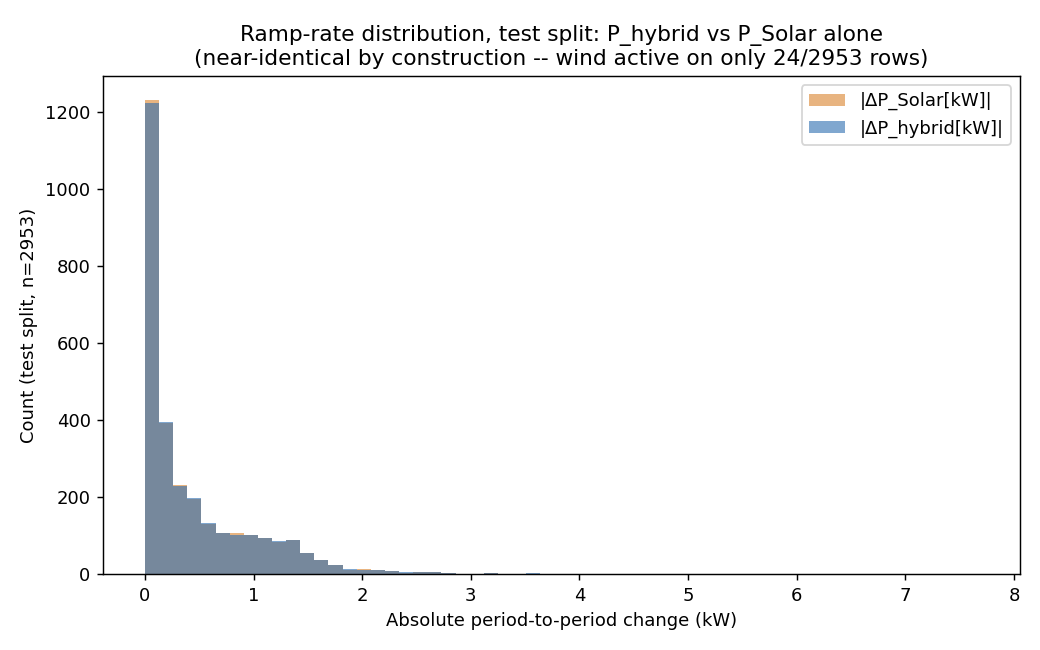

In [6]:
display(Image(filename='results/hybrid_ramp_rate_histogram.png'))


**Test-split-wide finding:** effectively no difference between `P_hybrid[kW]`'s and
`P_Solar[kW]`'s ramp-rate distributions — they diverge at all on only 0.847% of scored
rows. This is not evidence of smoothing (or worsening); it's evidence there's almost no
wind signal present to smooth or worsen anything with.

**Narrow, n=2 case study — the two individually-known wind-active calendar days:**

,in_split,wind_active_hours,max_abs_delta_hybrid_kw,max_abs_delta_solar_kw,hours_where_hybrid_and_solar_ramps_differ,largest_single_divergence_kw
2018-08-31,train,24,2.136493,1.787854,25,1.600663
2019-05-25,test,24,7.669988,2.075814,25,7.669988


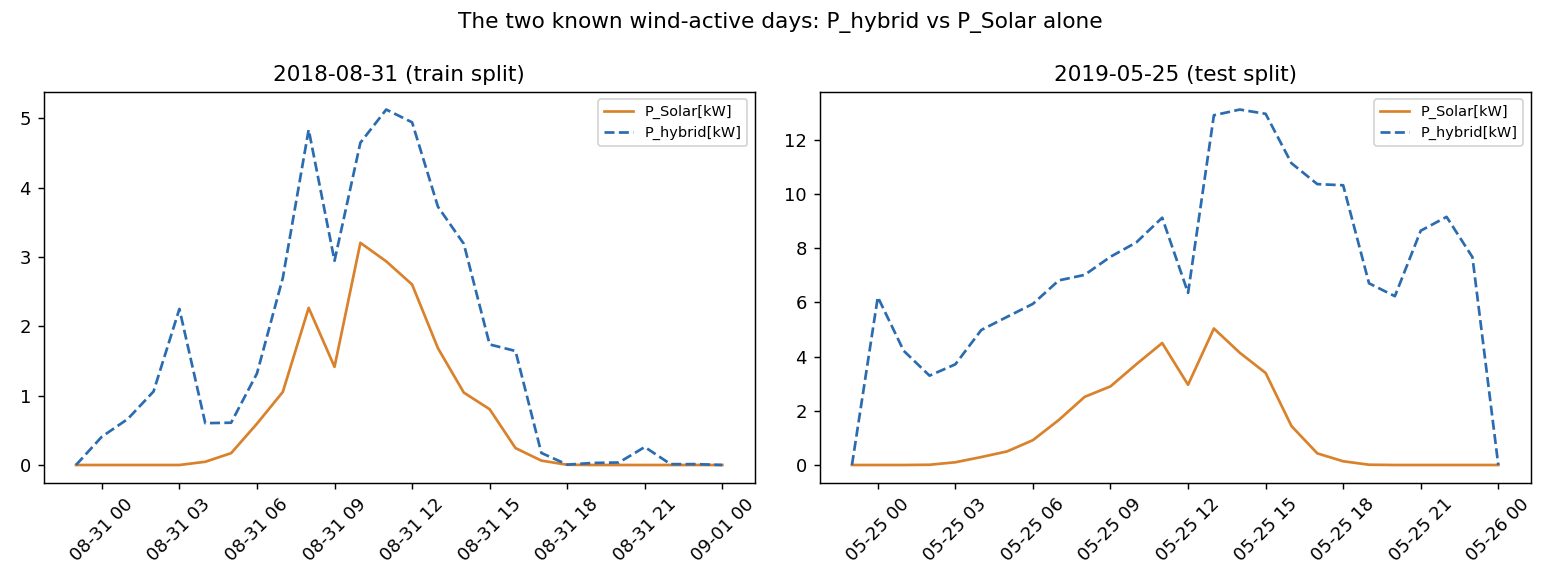

In [7]:
p2 = r63['part_2_two_known_active_days_case_study']
days_df = pd.DataFrame(p2['days']).T
display(days_df)
display(Image(filename='results/hybrid_ramp_rate_active_days.png'))


**Stated narrowly, as the data supports:** on both known wind-active days, wind power
coincides with solar's daytime output rather than filling a nighttime gap — so the
hybrid signal shows a **larger**, not smaller, peak-to-peak swing than solar alone (e.g.
7.67 kW vs. 2.08 kW max step-change on 2019-05-25). If anything, wind *added* ramp
magnitude on these two specific days rather than smoothing it. This is an observation
about two calendar days, not a general claim about wind-solar ramp behavior on this
dataset or in Danish wind-solar systems more broadly — n=2 does not support that
generalization, and this notebook does not make it.

## Summary

- **Task 6.0:** test-split wind activity is 0.81% of rows, 3.86% of `P_hybrid[kW]`
  energy, 11.36% of its variance, with ~zero solar-wind covariance. **Decision: path
  (b)** — build and document the infrastructure; do not claim a complementarity finding
  this data can't support.
- **Task 6.1:** `P_hybrid[kW]` and its QC inheritance (`P_hybrid[kW]_qc` /
  `P_hybrid[kW]_qc_source`) are implemented in `Functions.py` and documented in
  `QC_SCHEMA.md` / `DATA_DICTIONARY.md`.
- **Task 6.2:** joint vs. independent AR forecasting differ by −0.013 kW — not
  distinguishable from noise given how little real wind signal exists in the test split.
- **Task 6.3:** ramp-rate distributions are effectively identical between `P_hybrid[kW]`
  and `P_Solar[kW]` test-split-wide; on the two known active days specifically, wind
  added to the ramp magnitude rather than smoothing it (n=2, not generalizable).
- **This is an infrastructure + honest-limitation result, not a flagship complementarity
  finding.** The wind record's near-total zero-degeneracy is itself unresolved
  (`KNOWN_ISSUES.md` #10) — possibly a real turbine outage, possibly a
  resolution/aggregation pipeline artifact — and the maintainer is pursuing better raw
  data from the original project to settle it. Every script in this phase
  (`task6_2_hybrid_joint_vs_independent.py`, `task6_3_ramp_rate_analysis.py`) is written
  to be re-run unchanged against that data the moment it's available.